In [267]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [268]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [269]:
df=pd.read_csv(r"C:\Users\niyas\OneDrive\Desktop\NIYAS DSA\MAIN PROJECT\CSV\Last_agriculture_dataset(Y).csv")
df

,State,District,Year,Crop,Season,Area,Rainfall,Production,Nitrogen_Score,Phosphorus_Score,Potassium_Score,Acidic_Percent,Neutral_Percent,Alkaline_Percent
0,ANDAMAN & NICOBAR,NICOBARS,2000,Arecanut,Kharif,1254.0,2763.2,2000.0,17285,16863,17005,0.107919,0.892081,0.000000
1,ANDAMAN & NICOBAR,NICOBARS,2000,Other Kharif pulses,Kharif,2.0,2763.2,1.0,17285,16863,17005,0.107919,0.892081,0.000000
2,ANDAMAN & NICOBAR,NICOBARS,2000,Rice,Kharif,102.0,2763.2,321.0,17285,16863,17005,0.107919,0.892081,0.000000
3,ANDAMAN & NICOBAR,NICOBARS,2000,Banana,Whole Year,176.0,2763.2,641.0,17285,16863,17005,0.107919,0.892081,0.000000
4,ANDAMAN & NICOBAR,NICOBARS,2000,Cashewnut,Whole Year,720.0,2763.2,165.0,17285,16863,17005,0.107919,0.892081,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487835,WEST BENGAL,PURULIA,2014,Rice,Winter,279151.0,1261.4,597899.0,677010,1075630,895546,0.275584,0.723400,0.001017
487836,WEST BENGAL,PURULIA,2014,Sesamum,Winter,175.0,2322.6,88.0,27948,45448,36411,0.421447,0.578078,0.000476
487837,WEST BENGAL,PURULIA,2014,Sesamum,Winter,175.0,2322.6,88.0,677010,1075630,895546,0.275584,0.723400,0.001017
487838,WEST BENGAL,PURULIA,2014,Sesamum,Winter,175.0,1261.4,88.0,27948,45448,36411,0.421447,0.578078,0.000476


In [270]:
for i in df:
    print('Column Name         :',i,'\n')
    print('Unique Value        :',df[i].unique())
    print('No. of Unique Value :',df[i].nunique())
    print('\n\n\n')

Column Name         : State 

Unique Value        : ['ANDAMAN & NICOBAR' 'ANDHRA PRADESH' 'ARUNACHAL PRADESH' 'ASSAM' 'BIHAR'
 'HARYANA' 'CHHATTISGARH' 'GUJARAT' 'GOA' 'HIMACHAL PRADESH'
 'JAMMU & KASHMIR' 'JHARKHAND' 'KARNATAKA' 'KERALA' 'MADHYA PRADESH'
 'MAHARASHTRA' 'NAGALAND' 'ODISHA' 'TAMIL NADU' 'PUNJAB' 'RAJASTHAN'
 'WEST BENGAL' 'TELANGANA' 'UTTAR PRADESH' 'UTTARAKHAND']
No. of Unique Value : 25




Column Name         : District 

Unique Value        : ['NICOBARS' 'NORTH AND MIDDLE ANDAMAN' 'SOUTH ANDAMANS' 'ANANTAPUR'
 'CHITTOOR' 'EAST GODAVARI' 'GUNTUR' 'KADAPA' 'KRISHNA' 'KURNOOL'
 'PRAKASAM' 'SPSR NELLORE' 'SRIKAKULAM' 'VISAKHAPATANAM' 'VIZIANAGARAM'
 'WEST GODAVARI' 'ANJAW' 'CHANGLANG' 'DIBANG VALLEY' 'EAST KAMENG'
 'EAST SIANG' 'KURUNG KUMEY' 'LOHIT' 'LONGDING' 'LOWER DIBANG VALLEY'
 'LOWER SUBANSIRI' 'NAMSAI' 'PAPUM PARE' 'TAWANG' 'TIRAP' 'UPPER SIANG'
 'UPPER SUBANSIRI' 'WEST KAMENG' 'WEST SIANG' 'BAKSA' 'BARPETA'
 'BONGAIGAON' 'CACHAR' 'CHIRANG' 'DARRANG' 'DHEMAJI' '

In [271]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487840 entries, 0 to 487839
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   State             487840 non-null  object 
 1   District          487840 non-null  object 
 2   Year              487840 non-null  int64  
 3   Crop              487840 non-null  object 
 4   Season            487840 non-null  object 
 5   Area              487840 non-null  float64
 6   Rainfall          485364 non-null  float64
 7   Production        482359 non-null  float64
 8   Nitrogen_Score    487840 non-null  int64  
 9   Phosphorus_Score  487840 non-null  int64  
 10  Potassium_Score   487840 non-null  int64  
 11  Acidic_Percent    487840 non-null  float64
 12  Neutral_Percent   487840 non-null  float64
 13  Alkaline_Percent  487840 non-null  float64
dtypes: float64(6), int64(4), object(4)
memory usage: 52.1+ MB


In [272]:
df.describe(include='all')

,State,District,Year,Crop,Season,Area,Rainfall,Production,Nitrogen_Score,Phosphorus_Score,Potassium_Score,Acidic_Percent,Neutral_Percent,Alkaline_Percent
count,487840,487840,487840.000000,487840,487840,4.878400e+05,485364.000000,4.823590e+05,4.878400e+05,4.878400e+05,4.878400e+05,487840.000000,487840.000000,487840.000000
unique,25,646,NaN,124,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,UTTAR PRADESH,TUMKUR,NaN,Rice,Kharif,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,66612,2808,NaN,29243,196705,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2005.665464,NaN,NaN,1.270587e+04,1307.005456,3.858983e+05,6.555411e+05,1.231237e+06,1.257831e+06,0.133481,0.842147,0.024372
std,NaN,NaN,4.963683,NaN,NaN,6.131260e+04,813.663595,1.320992e+07,5.908557e+05,1.052726e+06,1.105960e+06,0.199755,0.188947,0.034940
min,NaN,NaN,1997.000000,NaN,NaN,4.000000e-02,92.400000,0.000000e+00,0.000000e+00,5.260000e+02,4.220000e+02,0.000000,0.125597,0.000000
25%,NaN,NaN,2002.000000,NaN,NaN,9.000000e+01,741.900000,9.800000e+01,1.060650e+05,4.794460e+05,4.430520e+05,0.004547,0.723400,0.001017
50%,NaN,NaN,2006.000000,NaN,NaN,6.010000e+02,1052.700000,7.770000e+02,4.161640e+05,8.885650e+05,8.955460e+05,0.030503,0.934533,0.007109
75%,NaN,NaN,2010.000000,NaN,NaN,4.742000e+03,1632.700000,7.500000e+03,1.049224e+06,1.836446e+06,2.445836e+06,0.275584,0.975517,0.038594


In [273]:
df.isna().sum()

State                  0
District               0
Year                   0
Crop                   0
Season                 0
Area                   0
Rainfall            2476
Production          5481
Nitrogen_Score         0
Phosphorus_Score       0
Potassium_Score        0
Acidic_Percent         0
Neutral_Percent        0
Alkaline_Percent       0
dtype: int64

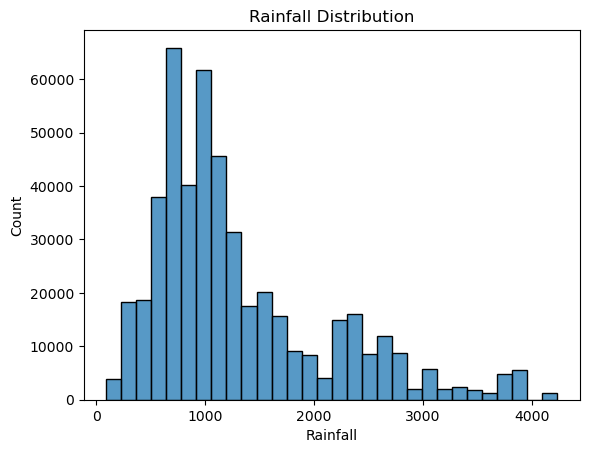

In [274]:
sns.histplot(df['Rainfall'], bins=30)

plt.title("Rainfall Distribution")
plt.show()

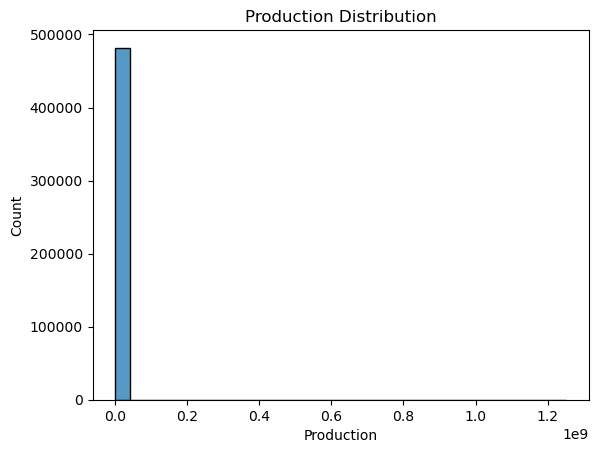

In [275]:
sns.histplot(df['Production'], bins=30)

plt.title("Production Distribution")
plt.show()

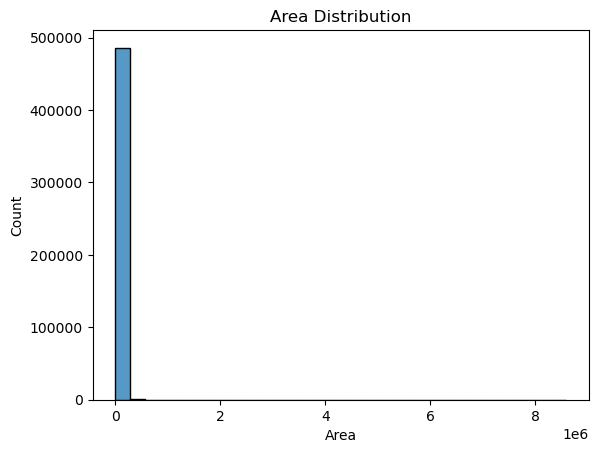

In [276]:
sns.histplot(df['Area'], bins=30)

plt.title("Area Distribution")
plt.show()

In [277]:
df.dropna(inplace=True)

In [278]:
df.isna().sum()

State               0
District            0
Year                0
Crop                0
Season              0
Area                0
Rainfall            0
Production          0
Nitrogen_Score      0
Phosphorus_Score    0
Potassium_Score     0
Acidic_Percent      0
Neutral_Percent     0
Alkaline_Percent    0
dtype: int64

In [279]:
print(df.duplicated().sum())

0


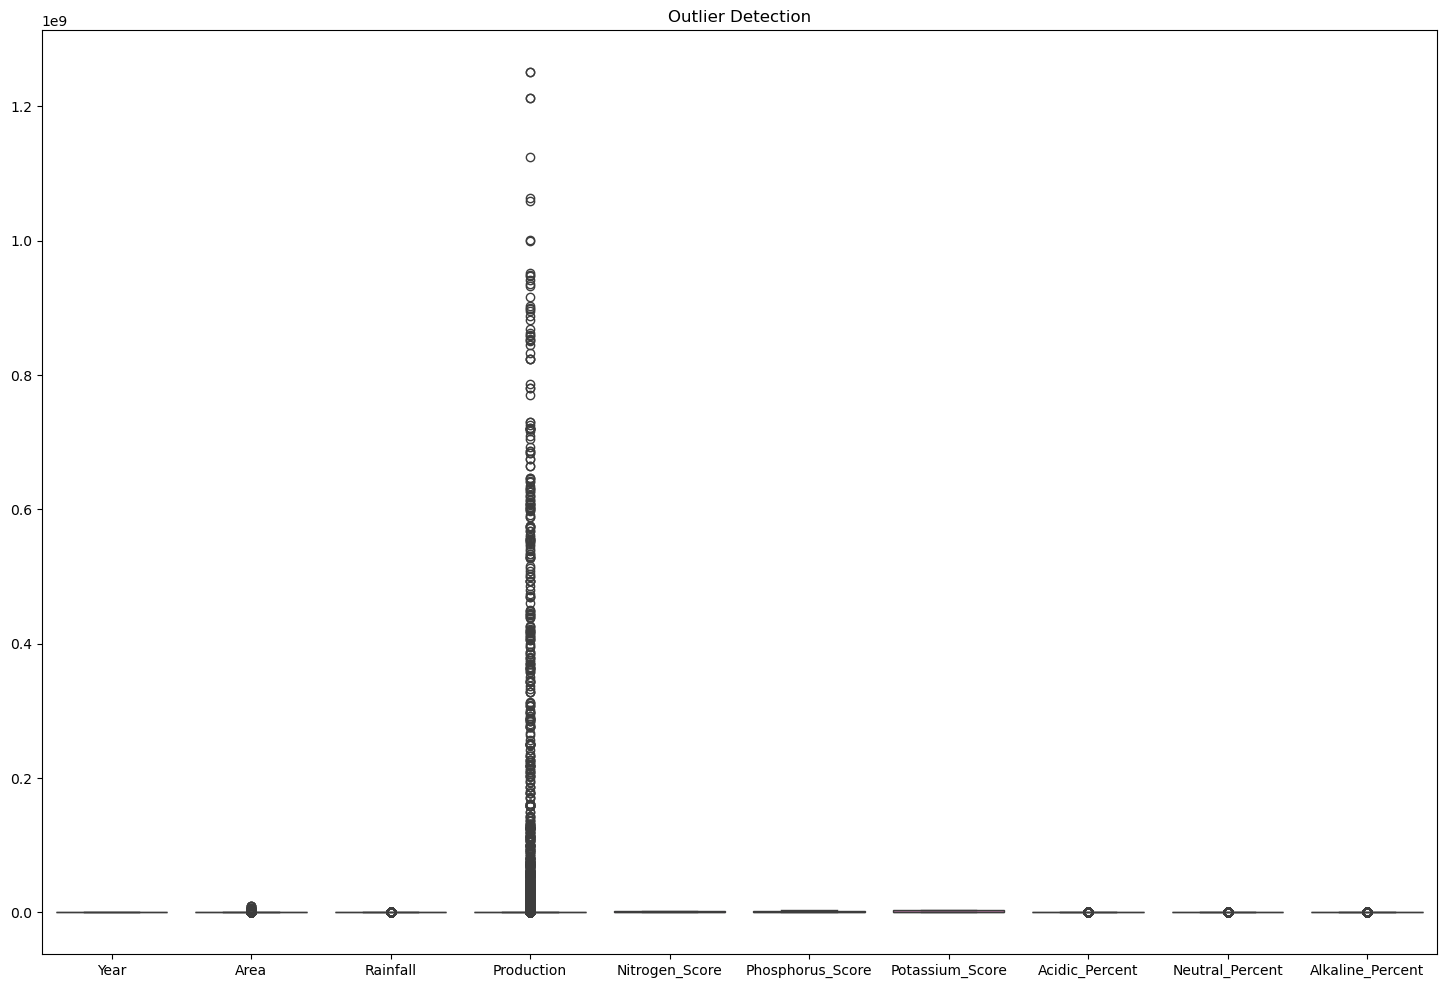

In [280]:
plt.figure(figsize=(18,12))

sns.boxplot(data=df)

plt.title('Outlier Detection')

plt.show()

In [281]:
df = df[df['Production'] > 0]

In [282]:
Q1 = df['Production'].quantile(0.25)
Q3 = df['Production'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['Production'] >= lower) &
    (df['Production'] <= upper)
]

In [283]:
df['Production'] = np.log1p(df['Production'])

In [284]:
df['Area'] = np.log1p(df['Area'])

In [285]:
df['Yield'] = df['Production'] / df['Area']

In [286]:
df.describe()

,Year,Area,Rainfall,Production,Nitrogen_Score,Phosphorus_Score,Potassium_Score,Acidic_Percent,Neutral_Percent,Alkaline_Percent,Yield
count,391342.000000,391342.000000,391342.000000,391342.000000,3.913420e+05,3.913420e+05,3.913420e+05,391342.000000,391342.000000,391342.000000,391342.000000
mean,2005.723117,5.773090,1337.984589,5.834327,6.481661e+05,1.206657e+06,1.227079e+06,0.144417,0.832439,0.023144,1.045504
std,4.954998,2.302265,816.301303,2.347114,5.901394e+05,1.061495e+06,1.110742e+06,0.208017,0.197064,0.034275,0.368671
min,1997.000000,0.095310,92.400000,0.009950,0.000000e+00,5.260000e+02,4.220000e+02,0.000000,0.125597,0.000000,0.001244
25%,2002.000000,4.189655,755.800000,4.218404,1.060650e+05,4.794460e+05,4.430520e+05,0.004547,0.723400,0.001017,0.878881
50%,2006.000000,5.846439,1067.200000,5.993961,4.161640e+05,8.245320e+05,8.602050e+05,0.032309,0.934533,0.007109,0.979407
75%,2010.000000,7.504392,1716.900000,7.716461,1.049224e+06,1.836446e+06,2.445836e+06,0.275584,0.975517,0.038594,1.105903
max,2015.000000,13.782598,4229.400000,9.869000,1.681589e+06,3.228891e+06,3.186523e+06,0.874368,0.994709,0.152129,13.834372


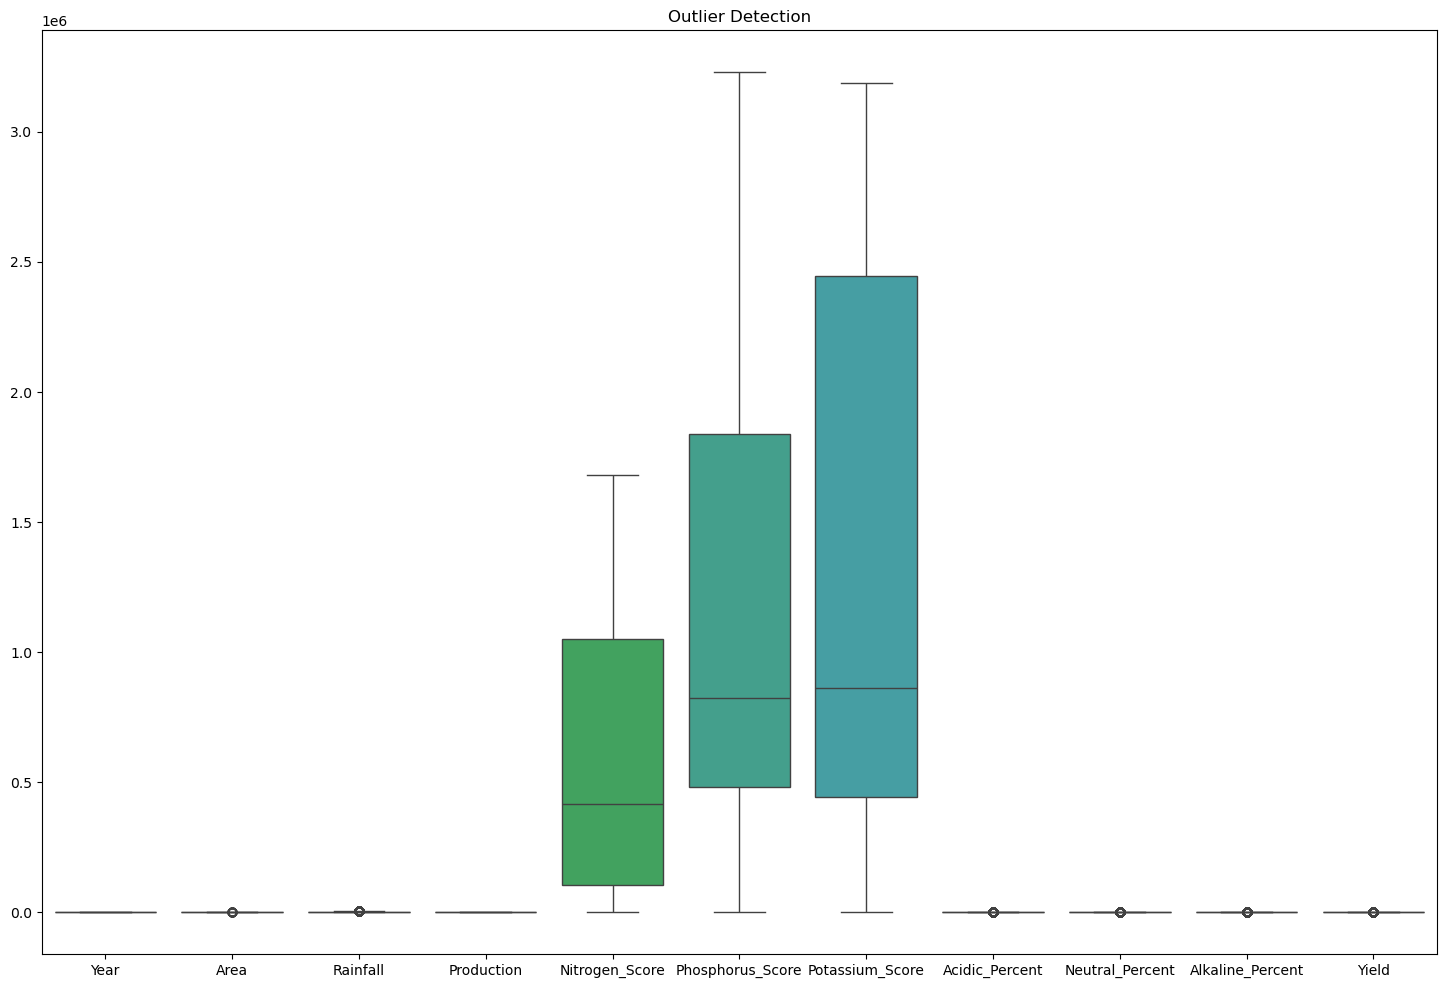

In [287]:
plt.figure(figsize=(18,12))

sns.boxplot(data=df)

plt.title('Outlier Detection')

plt.show()

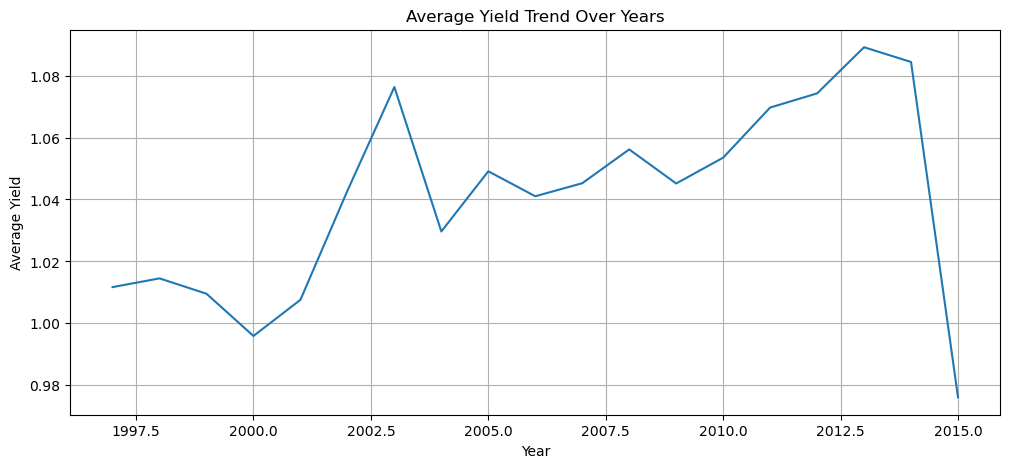

In [291]:
import matplotlib.pyplot as plt

yearly_yield = df.groupby('Year')['Yield'].mean()

plt.figure(figsize=(12,5))

plt.plot(yearly_yield.index, yearly_yield.values)

plt.xlabel("Year")
plt.ylabel("Average Yield")
plt.title("Average Yield Trend Over Years")

plt.grid(True)

plt.show()

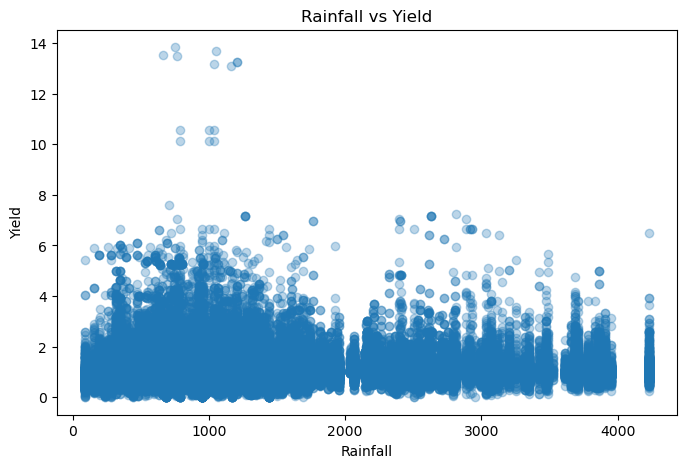

In [292]:
plt.figure(figsize=(8,5))

plt.scatter(df['Rainfall'], df['Yield'], alpha=0.3)

plt.xlabel("Rainfall")
plt.ylabel("Yield")

plt.title("Rainfall vs Yield")

plt.show()

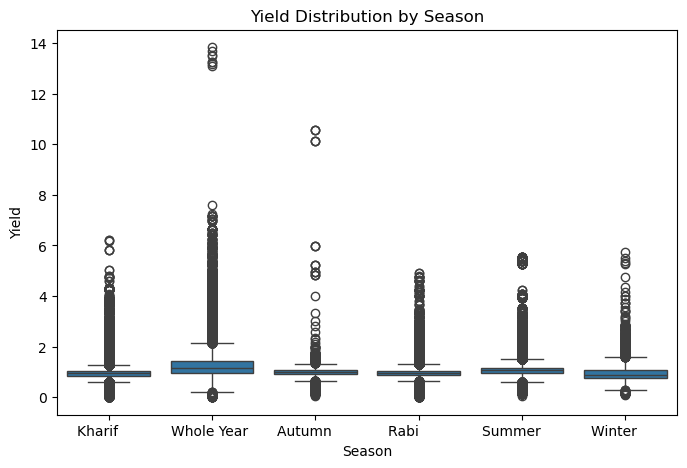

In [294]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(x='Season', y='Yield', data=df)

plt.title("Yield Distribution by Season")

plt.show()

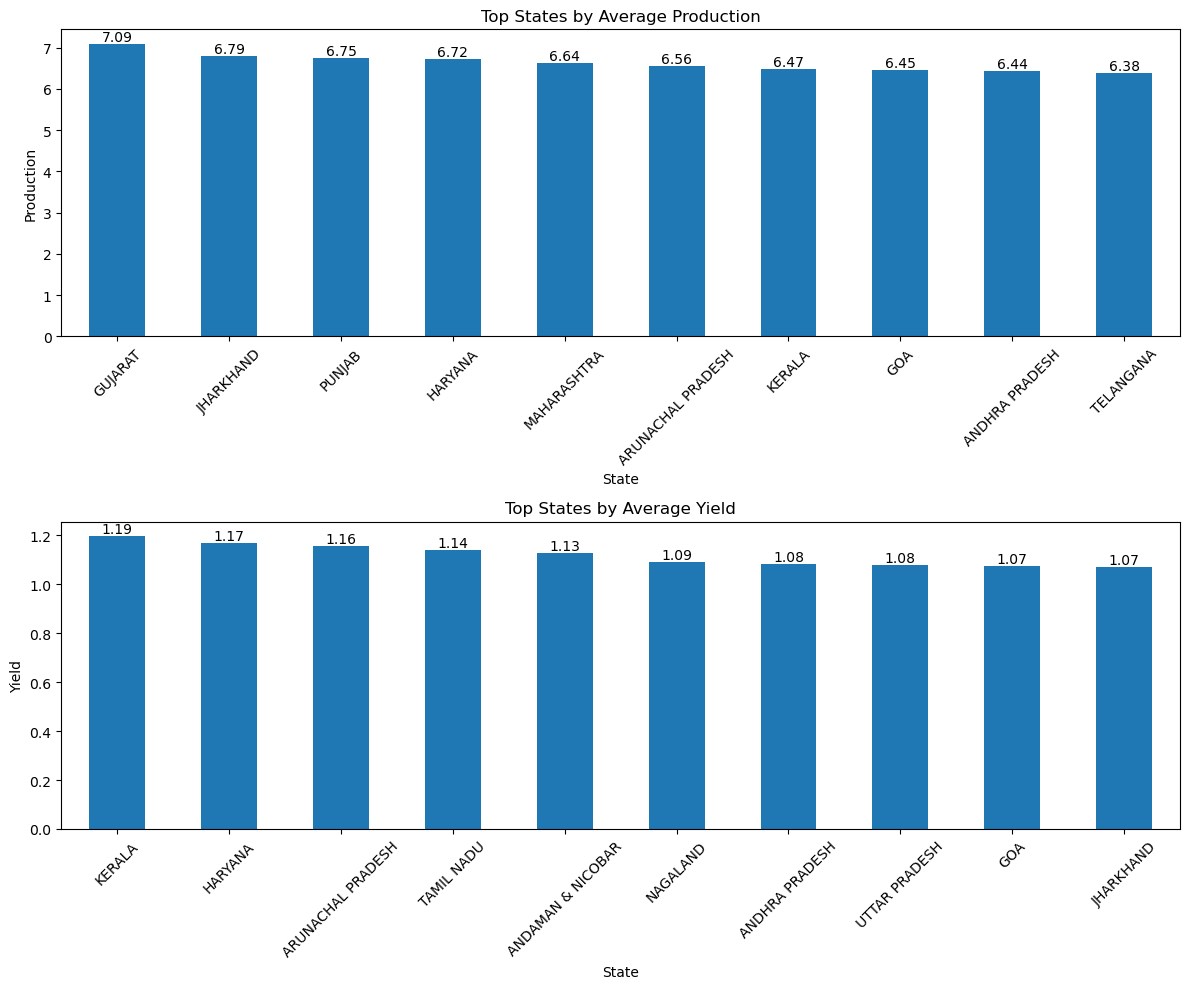

In [ ]:
state_yield = df.groupby('State')[['Production','Yield']].mean()

state_yield = state_yield.sort_values(
    by='Production',
    ascending=False
)

top10 = state_yield.head(10)

# =====================================
# SUBPLOTS
# =====================================

fig, axes = plt.subplots(
    2, 1,
    figsize=(12,10)
)

# =====================================
# PRODUCTION
# =====================================

top10['Production'].plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title("Top States by Average Production")

axes[0].set_ylabel("Production")

axes[0].tick_params(axis='x', rotation=45)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f')

# =====================================
# YIELD
# =====================================

state_yield = df.groupby('State')[['Production','Yield']].mean()

state_yield = state_yield.sort_values(
    by='Yield',
    ascending=False
)

top10 = state_yield.head(10)

top10['Yield'].plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title("Top States by Average Yield")

axes[1].set_ylabel("Yield")

axes[1].tick_params(axis='x', rotation=45)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f')

plt.tight_layout()

plt.show()

plt.show()

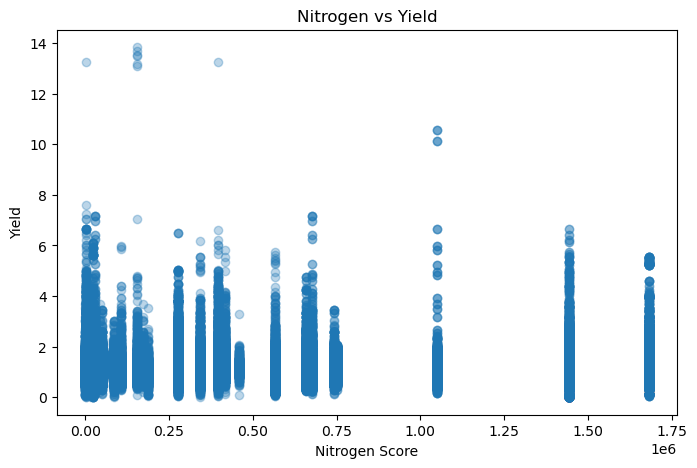

In [306]:
plt.figure(figsize=(8,5))

plt.scatter(df['Nitrogen_Score'], df['Yield'], alpha=0.3)

plt.xlabel("Nitrogen Score")
plt.ylabel("Yield")

plt.title("Nitrogen vs Yield")

plt.show()

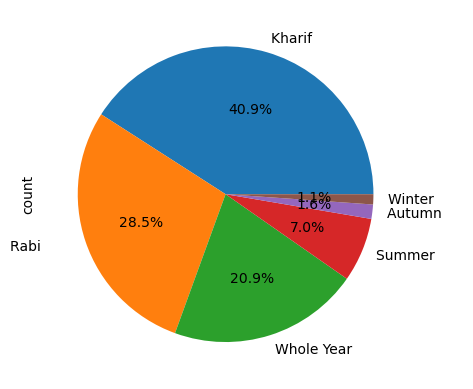

In [335]:
df['Season'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

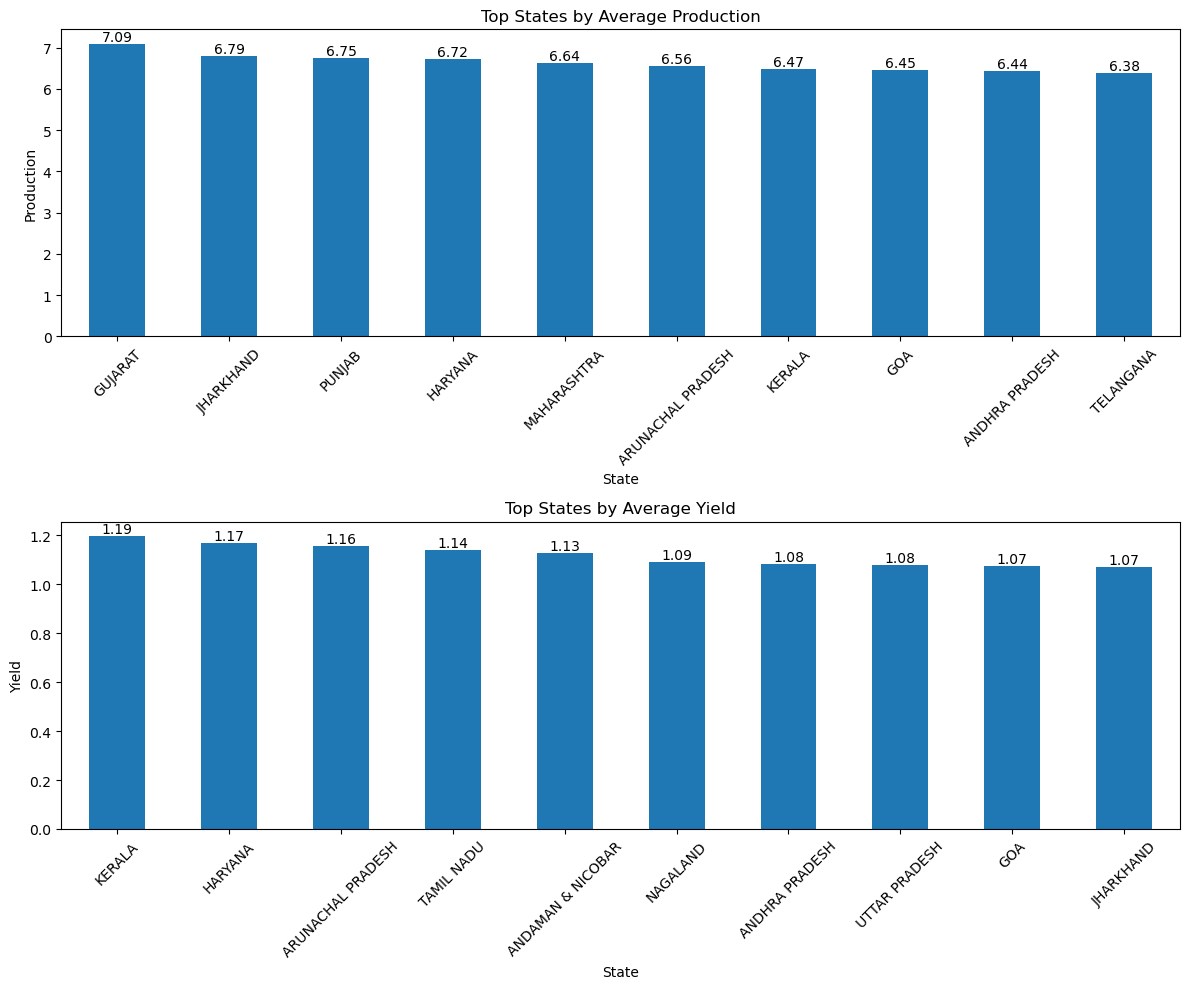

In [366]:
state_yield = df.groupby('State')[['Production','Yield']].mean()

state_yield = state_yield.sort_values(
    by='Production',
    ascending=False
)

top10 = state_yield.head(10)

# =====================================
# SUBPLOTS
# =====================================

fig, axes = plt.subplots(
    2, 1,
    figsize=(12,10)
)

# =====================================
# PRODUCTION
# =====================================

top10['Production'].plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title("Top States by Average Production")

axes[0].set_ylabel("Production")

axes[0].tick_params(axis='x', rotation=45)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f')

# =====================================
# YIELD
# =====================================

state_yield = df.groupby('State')[['Production','Yield']].mean()

state_yield = state_yield.sort_values(
    by='Yield',
    ascending=False
)

top10 = state_yield.head(10)

top10['Yield'].plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title("Top States by Average Yield")

axes[1].set_ylabel("Yield")

axes[1].tick_params(axis='x', rotation=45)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f')

plt.tight_layout()

plt.show()

plt.show()

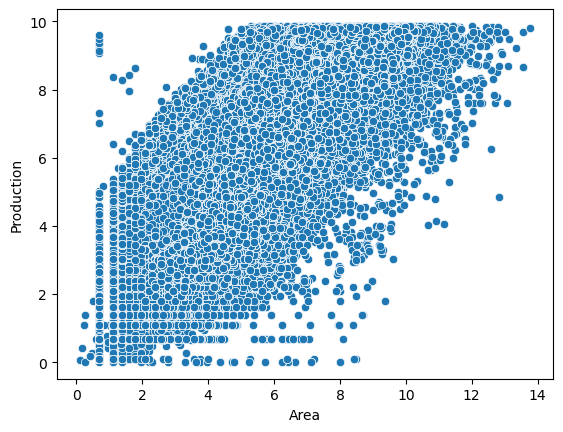

In [317]:
sns.scatterplot( x='Area', y='Production', data=df)

plt.show()

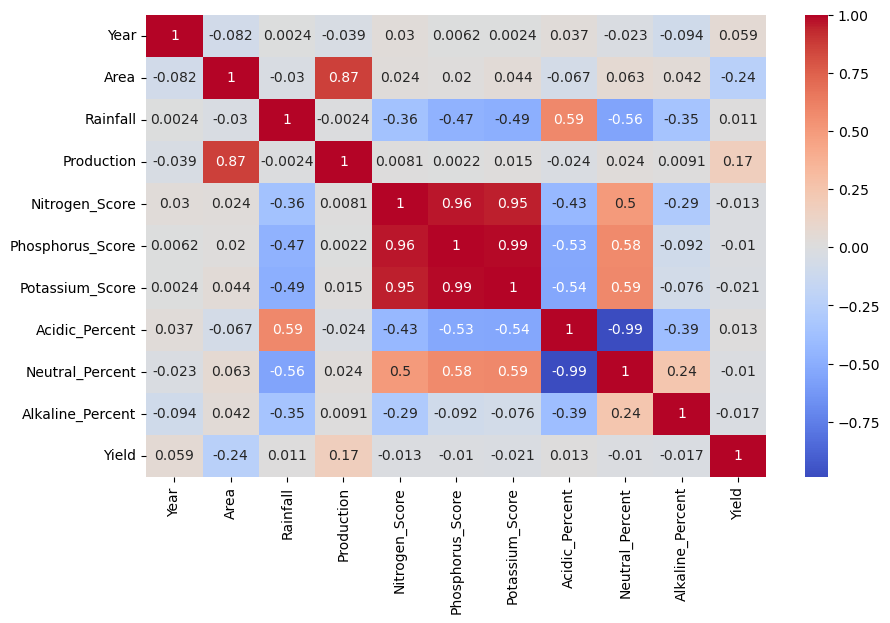

In [316]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [367]:
district_map = df[['State', 'District']].drop_duplicates()

In [ ]:
import joblib

joblib.dump(district_map, r"C:\Users\niyas\OneDrive\Desktop\NIYAS DSA\MAIN PROJECT\App\district_map.pkl")

['district_map.pkl']

In [369]:
df.shape

(391342, 15)

In [370]:
df.drop(['Year','Nitrogen_Score','Phosphorus_Score',
         'Potassium_Score','Acidic_Percent','Neutral_Percent',
         'Alkaline_Percent'],axis=1,inplace=True)

In [371]:
print(df.duplicated().sum())

65035


In [372]:
df.drop_duplicates(inplace=True)

print(df.duplicated().sum())

0


In [ ]:
cat_cols= df.select_dtypes('object')

state_encoder = LabelEncoder()
district_encoder = LabelEncoder()
crop_encoder = LabelEncoder()
season_encoder = LabelEncoder()

df['State'] = state_encoder.fit_transform(df['State'])
df['District'] = district_encoder.fit_transform(df['District'])
df['Crop'] = crop_encoder.fit_transform(df['Crop'])
df['Season'] = season_encoder.fit_transform(df['Season'])

# Save encoders
joblib.dump(state_encoder, r"C:\Users\niyas\OneDrive\Desktop\NIYAS DSA\MAIN PROJECT\App\state_encoder.pkl")
joblib.dump(district_encoder, r"C:\Users\niyas\OneDrive\Desktop\NIYAS DSA\MAIN PROJECT\App\district_encoder.pkl")
joblib.dump(crop_encoder, r"C:\Users\niyas\OneDrive\Desktop\NIYAS DSA\MAIN PROJECT\App\crop_encoder.pkl")
joblib.dump(season_encoder, r"C:\Users\niyas\OneDrive\Desktop\NIYAS DSA\MAIN PROJECT\App\season_encoder.pkl")

['season_encoder.pkl']

In [374]:
df

,State,District,Crop,Season,Area,Rainfall,Production,Yield
0,0,427,1,1,7.134891,2763.2,7.601402,1.065385
1,0,427,65,1,1.098612,2763.2,0.693147,0.630930
2,0,427,80,1,4.634729,2763.2,5.774552,1.245931
3,0,427,5,4,5.176150,2763.2,6.464588,1.248918
4,0,427,18,4,6.580639,2763.2,5.111988,0.776822
...,...,...,...,...,...,...,...,...
487826,24,471,87,3,6.442540,1261.4,6.139885,0.953022
487828,24,471,90,4,5.783825,2322.6,9.695910,1.676384
487830,24,471,90,4,5.783825,1261.4,9.695910,1.676384
487836,24,471,87,5,5.170484,2322.6,4.488636,0.868127


In [375]:
x=df.drop(['Production','Yield'],axis=1)
y = df['Yield']

In [376]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [377]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(xtrain, ytrain)

pred = rf.predict(xtest)

In [378]:
print("MAE:", mean_absolute_error(ytest, pred))

print("MSE:", mean_squared_error(ytest, pred))

print("RMSE:", np.sqrt(mean_squared_error(ytest, pred)))

print("R2 Score:", r2_score(ytest, pred))

MAE: 0.046650550938234295
MSE: 0.010481347162711985
RMSE: 0.10237845067548143
R2 Score: 0.9253311128394489


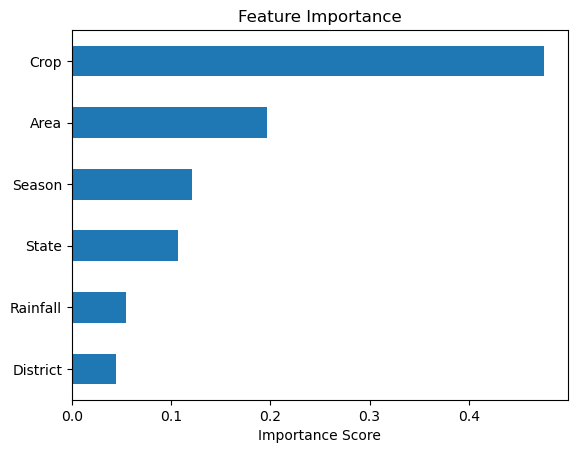

In [379]:
importance = rf.feature_importances_

features = x.columns

pd.Series(importance, index=features).sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [380]:
importance = pd.Series(
    rf.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

print(importance)

Crop        0.475908
Area        0.197056
Season      0.120890
State       0.106729
Rainfall    0.054670
District    0.044747
dtype: float64


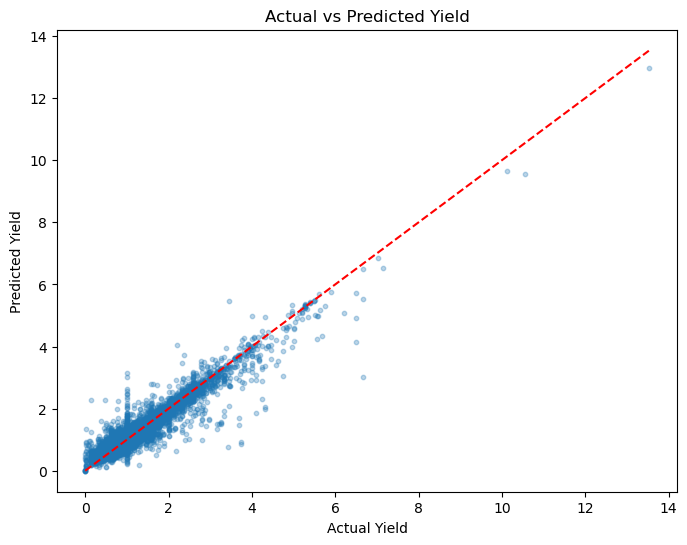

In [381]:
plt.figure(figsize=(8,6))

plt.scatter(
    ytest,
    pred,
    alpha=0.3,
    s=10
)

plt.plot(
    [ytest.min(), ytest.max()],
    [ytest.min(), ytest.max()],
    'r--'
)

plt.xlabel("Actual Yield")

plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Yield")

plt.show()

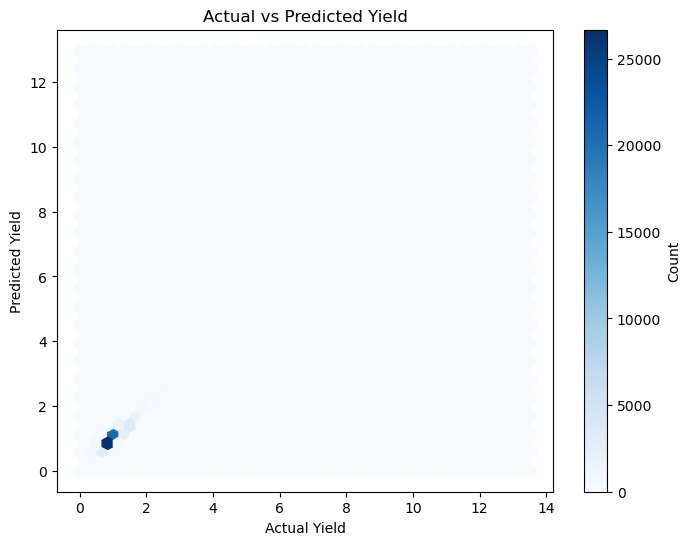

In [382]:
plt.figure(figsize=(8,6))

plt.hexbin(
    ytest,
    pred,
    gridsize=40,
    cmap='Blues'
)

plt.colorbar(label='Count')

plt.xlabel("Actual Yield")

plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Yield")

plt.show()

In [ ]:
# TO SAVE MODEL

import joblib

joblib.dump(rf, r"C:\Users\niyas\OneDrive\Desktop\NIYAS DSA\MAIN PROJECT\App\crop_yield_model.pkl")

['C:\\Users\\niyas\\OneDrive\\Desktop\\NIYAS DSA\\MAIN PROJECT\\crop_yield_model.pkl']

In [ ]:
model = joblib.load(r"C:\Users\niyas\OneDrive\Desktop\NIYAS DSA\MAIN PROJECT\App\crop_yield_model.pkl")